In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

from rdkit.Chem import MolFromSmiles, Draw, MolToSmiles
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import Chem, RDLogger
from chython import smiles

import pandas as pd
import numpy as np
from random import choice

import warnings
warnings.filterwarnings("ignore")
RDLogger.DisableLog('rdApp.*')

In [6]:
train_data = pd.read_csv('data/final_train_data80.csv', index_col=0)
test_data = pd.read_csv('data/final_test_data80.csv', index_col=0)

In [7]:
train_data.head()

,SMILES,LogP
ID,,
0,C1(NON=C1C2=CC=CC=C2)=N,3.093
1,C=1C=CC=CC=1CC(NC=2C=CC(=CC=2)Br)=O,5.245
2,C(C)C1=CC=CS1,4.294
3,N1C=CNC1=NC2C(OC)=NC(=NC2Cl)C,2.254
4,CC(C)CCO,1.939


In [8]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13403 entries, 0 to 13402
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   SMILES  13403 non-null  object 
 1   LogP    13403 non-null  float64
dtypes: float64(1), object(1)
memory usage: 314.1+ KB


In [58]:
METAL_LIST = ['Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Ga', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Cd', 'In', 'Sn',
              'La', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'Ac', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu',
              'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No',
              'Lr', 'Ge', 'Sb', 'Na', 'Ca']


def RemoveMetalls(mol_):
    """
    Check for metals in the molecule and return None if found, 
    otherwise, return the original molecule
    """
    
    return mol_ if not any(a.GetSymbol() in METAL_LIST for a in mol_.GetAtoms()) else None


def is_salt_by_chyton(mol):
    """
    Check whether a molecule is a salt based on the presence of ions.
    Returns None if the molecule contains ions (cations and anions)
    otherwise, return the original molecule
    """
    
    if smiles(MolToSmiles(mol)).neutralize():
        return None
    return mol

In [10]:
def canonicalize_smiles(smiles):
    '''
    Standardize SMILES using various methods of the rdkit library
    '''
    
    try:
        smiles, idx = smiles['SMILES'], smiles.index
        mol = MolFromSmiles(smiles)
        if mol is None:
            return None

        def apply_and_count(method_name, func):
            """Auxiliary function for counting the number of changes"""
            
            initial_smiles = MolToSmiles(mol)
            new_mol = func()
            if isinstance(new_mol, Chem.Mol):
                updated_smiles = MolToSmiles(new_mol)
            else:
                updated_smiles = MolToSmiles(mol)

            if initial_smiles != updated_smiles:
                method_counts[method_name] += 1
            if isinstance(new_mol, Chem.Mol):
                return new_mol
            return mol

        mol = apply_and_count("RemoveMetalls", lambda: RemoveMetalls(mol))
        mol = apply_and_count("RemoveSalt", lambda: is_salt_by_chyton(mol))
        mol = apply_and_count("SanitizeMol", lambda: Chem.SanitizeMol(mol))
        mol = apply_and_count('IsotopeParent', lambda: rdMolStandardize.IsotopeParent(mol))
        mol = apply_and_count('StereoParent', lambda: rdMolStandardize.StereoParent(mol))
        mol = apply_and_count('RemoveHs', lambda: Chem.RemoveHs(mol))
        mol = apply_and_count('FragmentParent', lambda: rdMolStandardize.FragmentParent(mol))
        mol = apply_and_count('Reionize', lambda: rdMolStandardize.Reionize(mol))
        mol = apply_and_count('ChargeParent', lambda: rdMolStandardize.ChargeParent(mol))
        normalizer = rdMolStandardize.Normalizer()
        mol = apply_and_count('Normalizer', lambda: normalizer.normalize(mol))
        tautomer_enumerator = rdMolStandardize.TautomerEnumerator()
        mol = apply_and_count('TautomerCanonicalize', lambda: tautomer_enumerator.Canonicalize(mol))
        mol = apply_and_count('SetAromaticity', lambda: Chem.rdmolops.SetAromaticity(mol))

        canonical_smiles = MolToSmiles(mol)
        return canonical_smiles

    except Exception as e:
        return None

In [11]:
method_counts = {
    "RemoveSalt": 0,
    "RemoveMetalls": 0,
    "SanitizeMol": 0,
    "Kekulize": 0,
    "RemoveHs": 0,
    "IsotopeParent": 0,
    "StereoParent": 0,
    "FragmentParent": 0,
    "ChargeParent": 0,
    "Normalizer": 0,
    "TautomerCanonicalize": 0,
    "MetalDisconnector": 0,
    "Reionize": 0,
    "SetAromaticity": 0,
    "AssignStereochemistry": 0
}

In [13]:
train_data['Smiles_cleaned'] = train_data.apply(canonicalize_smiles, axis=1)

In [14]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13403 entries, 0 to 13402
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SMILES          13403 non-null  object 
 1   LogP            13403 non-null  float64
 2   Smiles_cleaned  12953 non-null  object 
dtypes: float64(1), object(2)
memory usage: 418.8+ KB


In [15]:
train_data = train_data.dropna(subset=['Smiles_cleaned'])

In [17]:
train_data['Smiles_cleaned'].drop_duplicates().shape

(10820,)

In [18]:
def clean_logp_duplicates(df, smiles_col='Smiles_cleaned', logp_col='LogP'):
    '''
    Clear duplicate SMILES. The logP values of duplicates are grouped
    by proximity and the average value of the largest group is calculated. In the case
    if there are several groups of maximum size, the rows are deleted
    '''
    
    cleaned_rows = []
    TOLERANCE = 0.5

    for smiles, group in df.groupby(smiles_col):
        values = group[logp_col].values

        if len(values) == 1:
            cleaned_rows.append((group['SMILES'].values[0], smiles, values[0]))
            continue

        else:
            n = len(values)
            agreement_counts = [(i, values[i]) for i in range(n)]
            agreement_counts.sort(key=lambda x: x[1])
            count_groups = []
            i = 0
            for j in range(n):
                if abs(agreement_counts[i][1] - agreement_counts[j][1]) > TOLERANCE:
                    count_groups.append(agreement_counts[i:j])
                    i = j
                if j == n - 1:
                    count_groups.append(agreement_counts[i:j + 1])

            lens = list(map(len, count_groups))
            max_len = max(lens)
            if lens.count(max_len) > 1:
                continue
            else:
                target_group = max(count_groups, key=len)
                min_idx = min(list(map(lambda x: x[0], target_group)))
                target_values = list(map(lambda x: x[1], target_group))
                avg_logp = np.mean(target_values)

                cleaned_rows.append((group['SMILES'].values[min_idx], smiles, avg_logp))

    cleaned_df = pd.DataFrame(cleaned_rows, columns=['SMILES', smiles_col, logp_col])
    return cleaned_df

In [19]:
train_data_cleaned = clean_logp_duplicates(train_data)

In [20]:
train_data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10353 entries, 0 to 10352
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SMILES          10353 non-null  object 
 1   Smiles_cleaned  10353 non-null  object 
 2   LogP            10353 non-null  float64
dtypes: float64(1), object(2)
memory usage: 242.8+ KB


In [21]:
test_data['Smiles_cleaned'] = test_data.apply(canonicalize_smiles, axis=1)

In [24]:
train_data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10353 entries, 0 to 10352
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   SMILES          10353 non-null  object 
 1   Smiles_cleaned  10353 non-null  object 
 2   LogP            10353 non-null  float64
dtypes: float64(1), object(2)
memory usage: 242.8+ KB


In [25]:
def get_bounds_box(df):
    Q1 = df.quantile(0.25)
    Q3 = df.quantile(0.75)
    IQR = Q3 - Q1

    lower_whisker = Q1 - 1.5 * IQR
    upper_whisker = Q3 + 1.5 * IQR

    print(f"Lower whisker: {lower_whisker}")
    print(f'Mean: {df.mean()}')
    print(f"Upper whisker: {upper_whisker}")
    print(f'2.5% quantile: {df.quantile(0.025)}')
    print(f'97.5% quantile: {df.quantile(0.975)}')
    print(f'0.5% quantile: {df.quantile(0.005)}')
    print(f'99.5% quantile: {df.quantile(0.995)}')

In [26]:
get_bounds_box(train_data_cleaned['LogP'])

Lower whisker: -1.2325000000000008
Mean: 3.574664058726939
Upper whisker: 8.3155
2.5% quantile: -0.0787999999999999
97.5% quantile: 7.664
0.5% quantile: -1.8085200000000001
99.5% quantile: 9.094


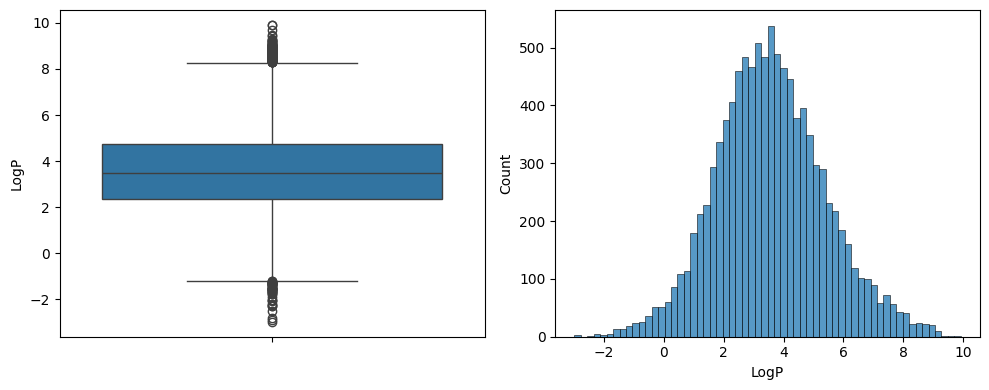

In [27]:
fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)
low = -3
high = 10
df_temp = train_data_cleaned['LogP'][(train_data_cleaned['LogP'] >= low) & (train_data_cleaned['LogP'] <= high)]
sns.boxplot(df_temp, ax=ax1)
sns.histplot(df_temp, ax=ax2)
plt.tight_layout()
plt.show()

In [32]:
filtered_df = train_data_cleaned[(train_data_cleaned['LogP'] >= -3) & (train_data_cleaned['LogP'] <= 10)]

In [42]:
def draw_with_nums(sm):
    mol = MolFromSmiles(sm)
    for atom in mol.GetAtoms():
        atom.SetProp("molAtomMapNumber", str(atom.GetIdx()))

    display(Draw.MolToImage(mol, kekulize=False, size=(300, 200)))

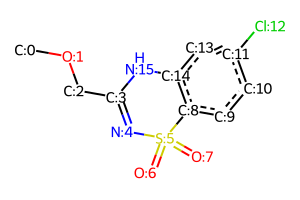

In [57]:
rnd_idx = choice(filtered_df.index)

draw_with_nums(filtered_df.loc[rnd_idx, 'Smiles_cleaned'])

In [47]:
filtered_df.to_csv('train_data.csv', index=False)
test_data.to_csv('test_data.csv', index=False)